# Teste avaliativo para vaga de bolsista em engenharia/análise de dados

## 1. Extração dos dados

In [102]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import re
import requests
import seaborn as sns
import sqlite3
import time

In [70]:
# CONFIGURAR PASTA PARA SALVAR OS DADOS DA REQUISIÇÃO
os.makedirs('data', exist_ok=True)


URL = 'https://api.obrasgov.gestao.gov.br/obrasgov/api'
ENDPOINT = 'projeto-investimento'
MAX_ATTEMPT = 2
PAGE_SIZE = 10
UF = 'DF'
page = 0 


# PROJETOS DO DF
projetos_DF = []

# BUSCAR DADOS UTILIZANDO A API FORNECIDA
while True:
    response = requests.get(f'{URL}/{ENDPOINT}?uf={UF}&pagina={page}&tamanhoDaPagina={PAGE_SIZE}')

    # se vir um erro 404 indica que aquela página não existe ou a requisição está falhando
    if response.status_code == 404:
        print(f'Página {page} não existe. Finalizando.')
        break

    # se vir um erro 429, siginifica que meu ip tá sendo negado, preciso aguardar o rate-limit imposto pela api
    elif response.status_code == 429:
        retry_after = int(response.headers.get('x-rate-limit-retry-after-seconds', 2))
        time.sleep(retry_after)
        continue

    try:
        data = response.json()
    except ValueError as e:
        print(f'Erro ao decodificar JSON na página {page}: {e}')
        break

    if not data.get("content") or data.get("empty", False):
        print(f'Acabaram os dados para o UF = {UF}. (page={page})')
        break
    
    projetos_DF.extend(data["content"])
    print(f'Página {page} processada com sucesso!', end='\r')
    page += 1
    time.sleep(2)
        

print(f'\nDados carregados. Total de dados encontrados = {len(projetos_DF)}.')


# SALVAR DADOS EM JSON:
json_path = os.path.join('data', 'projetos_DF.json')
with open(json_path, "w", encoding="utf-8") as file:
    json.dump(projetos_DF, file, ensure_ascii=False, indent=2)
print(f'Arquivo JSON salvo: {json_path}')


# SALVAR DADOS EM CSV:
csv_path = os.path.join('data', 'projetos_DF.csv')
df = pd.DataFrame(projetos_DF)
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f'Arquivo CSV salvo: {csv_path}')


# SALVAR DADOS EM PICKLE:
pkl_path = os.path.join('data', 'projetos_DF.pkl')
with open(pkl_path, "wb") as file:
    pickle.dump(projetos_DF, file)
print(f'Arquivo Pickle salvo: {pkl_path}')

Acabaram os dados para o UF = DF. (page=84)

Dados carregados. Total de dados encontrados = 834.
Arquivo JSON salvo: data/projetos_DF.json
Arquivo CSV salvo: data/projetos_DF.csv
Arquivo Pickle salvo: data/projetos_DF.pkl


## 2. Busca exploratória dos dados

### 2.1 Visão geral dos dados

In [161]:
df = pd.DataFrame(projetos_DF)

rows, cols = df.shape

print(f'Dimensões (Linhas x Colunas): {rows} x {cols}')
print(f'Quantidade de linhas: {rows}')
print(f'Quantidade de colunas: {cols}')
print(f'Total de dados: (linhas x colunas) = {rows * cols}\n')

Dimensões (Linhas x Colunas): 834 x 31
Quantidade de linhas: 834
Quantidade de colunas: 31
Total de dados: (linhas x colunas) = 25854



In [162]:
# quantidade de valores nulos
qtd_null = df.isnull().sum()

# porcentagem de valores nulos:
percent_null = qtd_null / len(df) * 100

print("DADOS NULOS POR COLUNAS DOS DADOS OBTIDOS:\n")

for col in df.columns:
    print(f'{col}: {qtd_null[col]} --- ({percent_null[col]:.2f}%)')

DADOS NULOS POR COLUNAS DOS DADOS OBTIDOS:

idUnico: 0 --- (0.00%)
nome: 0 --- (0.00%)
cep: 448 --- (53.72%)
endereco: 423 --- (50.72%)
descricao: 0 --- (0.00%)
funcaoSocial: 0 --- (0.00%)
metaGlobal: 0 --- (0.00%)
dataInicialPrevista: 1 --- (0.12%)
dataFinalPrevista: 1 --- (0.12%)
dataInicialEfetiva: 813 --- (97.48%)
dataFinalEfetiva: 830 --- (99.52%)
dataCadastro: 0 --- (0.00%)
especie: 3 --- (0.36%)
natureza: 0 --- (0.00%)
naturezaOutras: 619 --- (74.22%)
situacao: 0 --- (0.00%)
descPlanoNacionalPoliticaVinculado: 540 --- (64.75%)
uf: 0 --- (0.00%)
qdtEmpregosGerados: 662 --- (79.38%)
descPopulacaoBeneficiada: 653 --- (78.30%)
populacaoBeneficiada: 656 --- (78.66%)
observacoesPertinentes: 697 --- (83.57%)
isModeladaPorBim: 246 --- (29.50%)
dataSituacao: 0 --- (0.00%)
tomadores: 0 --- (0.00%)
executores: 0 --- (0.00%)
repassadores: 0 --- (0.00%)
eixos: 0 --- (0.00%)
tipos: 0 --- (0.00%)
subTipos: 0 --- (0.00%)
fontesDeRecurso: 0 --- (0.00%)


In [163]:
# informações do dataframe:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   idUnico                             834 non-null    object
 1   nome                                834 non-null    object
 2   cep                                 386 non-null    object
 3   endereco                            411 non-null    object
 4   descricao                           834 non-null    object
 5   funcaoSocial                        834 non-null    object
 6   metaGlobal                          834 non-null    object
 7   dataInicialPrevista                 833 non-null    object
 8   dataFinalPrevista                   833 non-null    object
 9   dataInicialEfetiva                  21 non-null     object
 10  dataFinalEfetiva                    4 non-null      object
 11  dataCadastro                        834 non-null    object

In [164]:
# descrição dos dados
df.describe()

,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,...,observacoesPertinentes,isModeladaPorBim,dataSituacao,tomadores,executores,repassadores,eixos,tipos,subTipos,fontesDeRecurso
count,834,834,386,411,834,834,834,833,833,21,...,137,588,834,834,834,834,834,834,834,834
unique,590,553,90,208,542,437,413,367,406,8,...,4,2,321,45,69,50,17,48,77,448
top,2745.53-81,CONSTRUÇÃO DE UNIDADE DE ATENÇÃO ESPECIALIZADA...,1,,CONSTRUÇÃO DE UNIDADE DE ATENÇÃO ESPECIALIZADA...,Segurança Pública,Escola de Educação Infantil Tipo B,2025-06-01,2027-06-01,2023-07-04,...,Informações Obras Fundo Nacional de Desenvolvi...,False,2025-07-25,[],[{'nome': 'FUNDO NACIONAL DE DESENVOLVIMENTO D...,[],"[{'id': 1, 'descricao': 'Administrativo'}]","[{'id': 22, 'descricao': 'Infraestrutura Hídri...","[{'id': 36, 'descricao': 'Dragagem, Derrocamen...","[{'origem': 'Federal', 'valorInvestimentoPrevi..."
freq,5,10,97,70,10,42,57,41,40,4,...,133,562,84,504,134,392,330,134,133,145


In [165]:
# ANÁLISE DE QUALIDADE DOS DADOS

print('=' * 80)
print('ANÁLISE DE QUALIDADE DOS DADOS')
print('=' * 80)

# Colunas que contêm listas
list_cols = ['tomadores', 'executores', 'repassadores', 'eixos', 'tipos', 'subTipos', 'fontesDeRecurso']

# Criar cópia do DataFrame para evitar alterar o original
df_hashable = df.copy()

# Transformar listas em strings para checagem de duplicatas
for col in df_hashable.columns:
    df_hashable[col] = df_hashable[col].apply(lambda x: str(x) if isinstance(x, list) else x)

# 1. Linhas duplicadas
rows_duplicated = df_hashable.duplicated().sum()
print(f'\n1. DUPLICATAS:')
print(f'   Quantidade de linhas duplicadas: {rows_duplicated}')
if rows_duplicated > 0:
    print(f'   Percentual de duplicatas: {(rows_duplicated/len(df_hashable)*100):.2f}%')

# 2. Valores nulos
total_null = df.isnull().sum().sum()
total_values = df.shape[0] * df.shape[1]
print(f'\n2. VALORES NULOS:')
print(f'   Total de valores nulos: {total_null}')
print(f'   Total de valores: {total_values}')
print(f'   Percentual de nulos: {(total_null/total_values*100):.2f}%')

# Top 5 colunas com mais valores nulos
print(f'\n   Top 5 colunas com mais valores nulos:')
null_counts = df.isnull().sum().sort_values(ascending=False).head()
for col, count in null_counts.items():
    pct = (count/len(df)*100)
    print(f'   {col}: {count} ({pct:.2f}%)')


ANÁLISE DE QUALIDADE DOS DADOS

1. DUPLICATAS:
   Quantidade de linhas duplicadas: 211
   Percentual de duplicatas: 25.30%

2. VALORES NULOS:
   Total de valores nulos: 6592
   Total de valores: 25854
   Percentual de nulos: 25.50%

   Top 5 colunas com mais valores nulos:
   dataFinalEfetiva: 830 (99.52%)
   dataInicialEfetiva: 813 (97.48%)
   observacoesPertinentes: 697 (83.57%)
   qdtEmpregosGerados: 662 (79.38%)
   populacaoBeneficiada: 656 (78.66%)


### 2.4 Problemas e Inconsistências Identificados

Com base na análise exploratória, foram identificados os seguintes problemas:

**Problemas de Completude:**
- Alta taxa de valores nulos em várias colunas importantes
- Campos de data podem estar incompletos ou mal formatados

**Problemas de Consistência:**
- Valores numéricos podem estar armazenados como texto
- Datas em formatos inconsistentes
- CEPs com formatos variados (com/sem máscara)
- Listas armazenadas como strings

**Ações de Tratamento:**
Todas essas inconsistências serão tratadas na próxima seção.

## 3. Tratamento dos dados

In [166]:
# TRATAMENTO DOS DADOS

new_df = df.copy()

# datas
DATE_COLS = [
    'dataInicialPrevista', 'dataFinalPrevista',
    'dataInicialEfetiva', 'dataFinalEfetiva',
    'dataCadastro', 'dataSituacao'
]

for date_col in DATE_COLS:
    if date_col in new_df.columns:
        new_df[date_col] = pd.to_datetime(new_df[date_col], errors='coerce')


# valores numericos
NUM_COLS = ['qdtEmpregosGerados', 'populacaoBeneficiada']

for num_col in NUM_COLS:
    if num_col in new_df.columns:
        new_df[num_col] = (
            new_df[num_col]
            .astype(str)
            .str.replace(r'[^0-9,.-]', '', regex=True)
            .str.replace(',', '.', regex=False)
        )
        new_df[num_col] = pd.to_numeric(new_df[num_col], errors='coerce')

# textos
TEXT_COLS = [
    'cep', 'descricao', 'endereco', 'nome', 'funcaoSocial', 
    'metaGlobal', 'descPopulacaoBeneficiada',
    'observacoesPertinentes', 'descPlanoNacionalPoliticaVinculado'
]
for col in TEXT_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].fillna('Não informado')
        
# tratando cep:
def tratar_cep(cep):
    if not cep or cep in ["nan", "NaN", "None"]:
        return ""
    digits = re.sub(r"\D", "", str(cep))
    return digits if len(digits) >= 8 else ""

new_df["cep"] = new_df["cep"].apply(tratar_cep)

        
# booleanos
BOOL_COLS = ['isModeladaPorBim']
for col in BOOL_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].fillna(False)
        

# categorias
CATEGORY_COLS = ['uf', 'situacao', 'especie', 'natureza']
for col in CATEGORY_COLS:
    if col in new_df.columns:
        new_df[col] = new_df[col].astype('category')
        
# normalizar os dados que são listas
columns_to_normalize = {
    "tomadores": "nome",
    "executores": "nome",
    "repassadores": "nome",
    "eixos": "descricao",
    "tipos": "descricao",
    "subTipos": "descricao",
    "fontesDeRecurso": "valorInvestimentoPrevisto"
}

for col, field in columns_to_normalize.items():
    # Nova coluna com o valor extraído
    col_name_capitalize = col.capitalize()
    new_col_name = f"{field}{col_name_capitalize}"
    new_df[new_col_name] = new_df[col].apply(
        lambda x: x[0][field] if isinstance(x, list) and len(x) > 0 and field in x[0] else None
    )
    new_df.drop(columns=[col], inplace=True)
    
new_df.info()
new_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   idUnico                                   834 non-null    object        
 1   nome                                      834 non-null    object        
 2   cep                                       834 non-null    object        
 3   endereco                                  834 non-null    object        
 4   descricao                                 834 non-null    object        
 5   funcaoSocial                              834 non-null    object        
 6   metaGlobal                                834 non-null    object        
 7   dataInicialPrevista                       833 non-null    datetime64[ns]
 8   dataFinalPrevista                         833 non-null    datetime64[ns]
 9   dataInicialEfetiva              

,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,...,observacoesPertinentes,isModeladaPorBim,dataSituacao,nomeTomadores,nomeExecutores,nomeRepassadores,descricaoEixos,descricaoTipos,descricaoSubtipos,valorInvestimentoPrevistoFontesderecurso
0,50379.53-54,DL - 304/2024 - Contratação de instituição par...,,Não informado,Contratação de instituição para execução de se...,Ampliação da capacidade de trafego visando a m...,Projetos Básicos e Executivos de Engenharia,2024-12-20,2027-12-05,NaT,...,Não informado,False,2024-12-20,None,DEPARTAMENTO NACIONAL DE INFRAESTRUTURA DE TRA...,None,Econômico,Rodovia,Acessos Terrestres,44463443.00
1,42724.53-27,Escola Classe Crixá São Sebastião,,Não informado,"Construção de Escola em Tempo Integral, Escola...",A construção da nova escola beneficiará 977 es...,"Construção de Escola em Tempo Integral, Escola...",2024-09-02,2028-09-02,NaT,...,Não informado,False,2025-09-05,None,SECRETARIA DE ESTADO DE EDUCACAO DO DISTRITO F...,FUNDO NACIONAL DE DESENVOLVIMENTO DA EDUCAÇÃO,Social,Educação,Educação,12319519.51
2,19970.53-78,Reajuste do Contrato 45/2021 - Contrução do Ce...,70602600,"SAIS Área Especial 3, Setor Policial Sul",Reajuste do Contrato 45/2021 - Construção do C...,Contribuir para a melhor formação dos bombeiro...,Construção de um novo centro de formação e de ...,2021-09-14,2024-08-28,NaT,...,Não informado,False,2023-02-06,None,CORPO DE BOMBEIROS MILITAR DO DISTRITO FEDERAL,CORPO DE BOMBEIROS MILITAR DO DISTRITO FEDERAL,Administrativo,Segurança Pública,Obras em Imóveis de Uso Público,1177429.91
3,24797.53-15,Implantação de Passarelas nas Estradas Parque ...,,Não informado,Implantação de passarelas de estrutura mista n...,"Pedestres, no geral, demanda das ocupações lin...",Implantação de passarelas de estrutura mista n...,2023-08-30,2028-08-30,NaT,...,Não informado,False,2023-08-28,None,DEPARTAMENTO DE ESTRADAS DE RODAGEM DO DISTRIT...,MINISTÉRIO DAS CIDADES,Econômico,Infraestrutura Urbana e Mobilidade,Obra de Arte Especial,10800000.00
4,24822.53-70,"obra de construção da Cabine de Medição, loca...",,Não informado,"obra de construção da Cabine de Medição, loca...",A demanda de carga elétrica do Campus Darcy Ri...,A demanda de carga elétrica do Campus Darcy Ri...,2023-09-14,2024-03-14,NaT,...,Não informado,False,2023-08-29,None,FUNDACAO UNIVERSIDADE DE BRASILIA,FUNDACAO UNIVERSIDADE DE BRASILIA,Econômico,Energia,Subestação,928139.70


In [167]:
# NORMALIZAR OS DADOS

# renomear colunas:

new_df = new_df.rename(
    columns=lambda x: x.replace('desc', 'descricao') if x.startswith('descP') else x
)

new_df = new_df.rename(
    columns=lambda x: x.replace('qdt', 'quantidade') if x.startswith('qdt') else x
)

new_df = new_df.rename(
    columns=lambda x: x.replace('is', 'eh') if x.startswith('is') else x
)

new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   idUnico                                   834 non-null    object        
 1   nome                                      834 non-null    object        
 2   cep                                       834 non-null    object        
 3   endereco                                  834 non-null    object        
 4   descricao                                 834 non-null    object        
 5   funcaoSocial                              834 non-null    object        
 6   metaGlobal                                834 non-null    object        
 7   dataInicialPrevista                       833 non-null    datetime64[ns]
 8   dataFinalPrevista                         833 non-null    datetime64[ns]
 9   dataInicialEfetiva              

In [168]:
# remover duplicatas pelo id, nomr e cep
new_df = new_df.drop_duplicates(subset=['idUnico', 'nome', 'cep'])

new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590 entries, 0 to 831
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   idUnico                                   590 non-null    object        
 1   nome                                      590 non-null    object        
 2   cep                                       590 non-null    object        
 3   endereco                                  590 non-null    object        
 4   descricao                                 590 non-null    object        
 5   funcaoSocial                              590 non-null    object        
 6   metaGlobal                                590 non-null    object        
 7   dataInicialPrevista                       589 non-null    datetime64[ns]
 8   dataFinalPrevista                         589 non-null    datetime64[ns]
 9   dataInicialEfetiva                   

In [169]:
# visualizando dados descritivos numericos e de datas:
new_df.describe()

,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,dataFinalEfetiva,dataCadastro,quantidadeEmpregosGerados,populacaoBeneficiada,dataSituacao,valorInvestimentoPrevistoFontesderecurso
count,589,589,12,3,590,24.000000,2.500000e+01,590,5.900000e+02
mean,2021-06-28 07:51:51.035653632,2023-05-31 22:51:32.699490816,2020-12-06 04:00:00,2023-02-23 16:00:00,2023-09-08 21:23:47.796610048,84.250000,4.407962e+05,2023-08-23 17:36:48.813559552,1.227511e+07
min,2003-06-26 00:00:00,2008-06-27 00:00:00,2018-05-17 00:00:00,2022-03-30 00:00:00,2021-01-19 00:00:00,0.000000,2.500000e+02,2009-09-15 00:00:00,0.000000e+00
25%,2020-10-19 00:00:00,2021-12-22 00:00:00,2018-06-25 18:00:00,2022-09-05 00:00:00,2022-02-04 06:00:00,20.000000,3.500000e+03,2022-03-23 06:00:00,7.574257e+04
50%,2022-03-30 00:00:00,2024-01-30 00:00:00,2019-11-01 00:00:00,2023-02-11 00:00:00,2023-12-05 00:00:00,55.000000,9.500000e+03,2023-12-28 00:00:00,1.130000e+06
75%,2024-01-17 00:00:00,2025-12-24 00:00:00,2023-11-18 00:00:00,2023-08-08 00:00:00,2025-05-05 00:00:00,100.000000,1.200000e+05,2025-05-05 00:00:00,5.942000e+06
max,2025-12-31 00:00:00,2032-02-27 00:00:00,2024-02-01 00:00:00,2024-02-02 00:00:00,2025-09-29 00:00:00,478.000000,4.291577e+06,2025-09-29 00:00:00,1.000000e+09
std,NaN,NaN,NaN,NaN,NaN,101.597351,1.127655e+06,NaN,5.862469e+07


In [170]:
# dados descritivos com textos
new_df.describe(include='object')

,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,naturezaOutras,descricaoPlanoNacionalPoliticaVinculado,descricaoPopulacaoBeneficiada,observacoesPertinentes,nomeTomadores,nomeExecutores,nomeRepassadores,descricaoEixos,descricaoTipos,descricaoSubtipos
count,590,590,590,590,590,590,590,158,590,590,590,245,587,317,587,587,587
unique,590,553,85,209,542,437,413,30,66,32,5,43,63,46,4,19,33
top,50379.53-54,202111-22-Ronald 1,,Não informado,2021122-Ronald - Descrição do Projeto,Segurança Pública,Escola de Educação Infantil Tipo B,,Não informado,Não informado,Não informado,INSTITUTO FED. ED. CIENCIA E TEC. DE BRASILIA,FUNDO NACIONAL DE DESENVOLVIMENTO DA EDUCAÇÃO,MINISTÉRIO DA EDUCAÇÃO,Administrativo,Administrativo,Obras em Imóveis de Uso Público
freq,1,7,394,283,7,33,44,100,383,473,500,48,88,57,247,105,182


In [171]:
new_df.head()

,idUnico,nome,cep,endereco,descricao,funcaoSocial,metaGlobal,dataInicialPrevista,dataFinalPrevista,dataInicialEfetiva,...,observacoesPertinentes,ehModeladaPorBim,dataSituacao,nomeTomadores,nomeExecutores,nomeRepassadores,descricaoEixos,descricaoTipos,descricaoSubtipos,valorInvestimentoPrevistoFontesderecurso
0,50379.53-54,DL - 304/2024 - Contratação de instituição par...,,Não informado,Contratação de instituição para execução de se...,Ampliação da capacidade de trafego visando a m...,Projetos Básicos e Executivos de Engenharia,2024-12-20,2027-12-05,NaT,...,Não informado,False,2024-12-20,None,DEPARTAMENTO NACIONAL DE INFRAESTRUTURA DE TRA...,None,Econômico,Rodovia,Acessos Terrestres,44463443.00
1,42724.53-27,Escola Classe Crixá São Sebastião,,Não informado,"Construção de Escola em Tempo Integral, Escola...",A construção da nova escola beneficiará 977 es...,"Construção de Escola em Tempo Integral, Escola...",2024-09-02,2028-09-02,NaT,...,Não informado,False,2025-09-05,None,SECRETARIA DE ESTADO DE EDUCACAO DO DISTRITO F...,FUNDO NACIONAL DE DESENVOLVIMENTO DA EDUCAÇÃO,Social,Educação,Educação,12319519.51
2,19970.53-78,Reajuste do Contrato 45/2021 - Contrução do Ce...,70602600,"SAIS Área Especial 3, Setor Policial Sul",Reajuste do Contrato 45/2021 - Construção do C...,Contribuir para a melhor formação dos bombeiro...,Construção de um novo centro de formação e de ...,2021-09-14,2024-08-28,NaT,...,Não informado,False,2023-02-06,None,CORPO DE BOMBEIROS MILITAR DO DISTRITO FEDERAL,CORPO DE BOMBEIROS MILITAR DO DISTRITO FEDERAL,Administrativo,Segurança Pública,Obras em Imóveis de Uso Público,1177429.91
3,24797.53-15,Implantação de Passarelas nas Estradas Parque ...,,Não informado,Implantação de passarelas de estrutura mista n...,"Pedestres, no geral, demanda das ocupações lin...",Implantação de passarelas de estrutura mista n...,2023-08-30,2028-08-30,NaT,...,Não informado,False,2023-08-28,None,DEPARTAMENTO DE ESTRADAS DE RODAGEM DO DISTRIT...,MINISTÉRIO DAS CIDADES,Econômico,Infraestrutura Urbana e Mobilidade,Obra de Arte Especial,10800000.00
4,24822.53-70,"obra de construção da Cabine de Medição, loca...",,Não informado,"obra de construção da Cabine de Medição, loca...",A demanda de carga elétrica do Campus Darcy Ri...,A demanda de carga elétrica do Campus Darcy Ri...,2023-09-14,2024-03-14,NaT,...,Não informado,False,2023-08-29,None,FUNDACAO UNIVERSIDADE DE BRASILIA,FUNDACAO UNIVERSIDADE DE BRASILIA,Econômico,Energia,Subestação,928139.70


## 4. Armazenamento dos dados

### 4.1. Justificativa do Banco de Dados

Foi utilizado um banco de dados sqlite para armazenar os dados de forma estruturada, para permitir consultas rápidas, garantir consistência e facilitar análises futuras.

### 4.2. Estrutura da Tabela

| Coluna                                      | Tipo      | Observação |
|--------------------------------------------|-----------|------------|
| idUnico                                     | TEXT      | PK         |
| nome                                        | TEXT      |            |
| cep                                         | TEXT      |            |
| endereco                                    | TEXT      |            |
| descricao                                   | TEXT      |            |
| funcaoSocial                                | TEXT      |            |
| metaGlobal                                  | TEXT      |            |
| dataInicialPrevista                          | DATE      |            |
| dataFinalPrevista                            | DATE      |            |
| dataInicialEfetiva                            | DATE      |            |
| dataFinalEfetiva                              | DATE      |            |
| dataCadastro                                | DATE      |            |
| especie                                     | TEXT      |            |
| natureza                                    | TEXT      |            |
| naturezaOutras                              | TEXT      |            |
| situacao                                    | TEXT      |            |
| descricaoPlanoNacionalPoliticaVinculado    | TEXT      |            |
| uf                                          | TEXT      |            |
| quantidadeEmpregosGerados                   | REAL      |            |
| descricaoPopulacaoBeneficiada               | TEXT      |            |
| populacaoBeneficiada                         | REAL      |            |
| observacoesPertinentes                       | TEXT      |            |
| ehModeladaPorBim                             | BOOLEAN   |            |
| dataSituacao                                | DATE      |            |
| nomeTomadores                               | TEXT      | Normalizado de lista |
| nomeExecutores                              | TEXT      | Normalizado de lista |
| nomeRepassadores                             | TEXT      | Normalizado de lista |
| descricaoEixos                               | TEXT      | Normalizado de lista |
| descricaoTipos                               | TEXT      | Normalizado de lista |
| descricaoSubtipos                            | TEXT      | Normalizado de lista |
| valorInvestimentoPrevistoFontesderecurso    | REAL      | Normalizado de lista |

In [172]:
# SALVAR OS DADOS NUM BANCO DE DADOS:

# irei utilizar o sqlite3, pois é um banco de dados relacional leve
# que já vem embutido no python, ideal para protótipos e projetos
# pequenos, além de não precisar de um servidor

PATH_DB = 'data/projetosDF.db'

# Iniciando conexão com o banco de dados
conn = sqlite3.connect(PATH_DB)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS projetos (
    idUnico TEXT PRIMARY KEY,
    nome TEXT,
    cep TEXT,
    endereco TEXT,
    descricao TEXT,
    funcaoSocial TEXT,
    metaGlobal TEXT,
    dataInicialPrevista DATE,
    dataFinalPrevista DATE,
    dataInicialEfetiva DATE,
    dataFinalEfetiva DATE,
    dataCadastro DATE,
    especie TEXT,
    natureza TEXT,
    naturezaOutras TEXT,
    situacao TEXT,
    descricaoPlanoNacionalPoliticaVinculado TEXT,
    uf TEXT,
    quantidadeEmpregosGerados REAL,
    descricaoPopulacaoBeneficiada TEXT,
    populacaoBeneficiada REAL,
    observacoesPertinentes TEXT,
    ehModeladaPorBim BOOLEAN,
    dataSituacao DATE,
    nomeTomadores TEXT,
    nomeExecutores TEXT,
    nomeRepassadores TEXT,
    descricaoEixos TEXT,
    descricaoTipos TEXT,
    descricaoSubtipos TEXT,
    valorInvestimentoPrevistoFontesderecurso REAL
)
""")

conn.commit()
print("Tabela 'projetos' criada com sucesso!")

Tabela 'projetos' criada com sucesso!


In [173]:
# INSERIR OS DADOS NA TABELA

conn = sqlite3.connect(PATH_DB)
cursor = conn.cursor()

def format_value(value):
    if pd.isna(value):
        return None
    elif isinstance(value, pd.Timestamp):
        return value.strftime('%Y-%m-%d')
    else:
        return value

cols = list(new_df.columns)
cols_placeholder = ', '.join('?' for _ in cols)
cols_names = ', '.join(cols)

data_to_insert = [
    tuple(format_value(x) for x in row)
    for row in new_df.itertuples(index=False, name=None)
]

cursor.executemany(f"""
    INSERT OR REPLACE INTO projetos ({cols_names})
    VALUES ({cols_placeholder})
""", data_to_insert)

conn.commit()
conn.close()

In [174]:
# VERIFICAR SE OS DADOS FORAM INSERIDOS CORRETAMENTE

print("=" * 80)
print("VERIFICAÇÃO DOS DADOS NO BANCO")
print("=" * 80)

conn = sqlite3.connect(PATH_DB)
cursor = conn.cursor()

# Contar registros
cursor.execute('SELECT COUNT(*) FROM projetos')
total = cursor.fetchone()[0]
print(f"\nTotal de registros inseridos: {total}")

# Mostrar primeiras 5 linhas
print(f"\nPrimeiras 5 linhas (idUnico, nome, situacao, dataCadastro):")
print("-" * 80)
cursor.execute('SELECT idUnico, nome, situacao, dataCadastro FROM projetos LIMIT 5')
for row in cursor.fetchall():
    print(f"ID: {row[0][:30]}... | Nome: {row[1][:30]}... | Situação: {row[2]} | Data Cadastro: {row[3]}")

# Verificar distribuição por situação
print(f"\n\nDistribuição por situação:")
print("-" * 80)
cursor.execute('SELECT situacao, COUNT(*) as total FROM projetos GROUP BY situacao ORDER BY total DESC')
for row in cursor.fetchall():
    print(f"{row[0]}: {row[1]} projetos")

conn.close()
print(f"\n{'=' * 80}")
print("Dados armazenados com sucesso no banco de dados!")
print(f"{'=' * 80}\n")

VERIFICAÇÃO DOS DADOS NO BANCO

Total de registros inseridos: 590

Primeiras 5 linhas (idUnico, nome, situacao, dataCadastro):
--------------------------------------------------------------------------------
ID: 50379.53-54... | Nome: DL - 304/2024 - Contratação de... | Situação: Cadastrada | Data Cadastro: 2024-12-20
ID: 42724.53-27... | Nome: Escola Classe Crixá São Sebast... | Situação: Cancelada | Data Cadastro: 2024-08-30
ID: 19970.53-78... | Nome: Reajuste do Contrato 45/2021 -... | Situação: Cadastrada | Data Cadastro: 2023-02-06
ID: 24797.53-15... | Nome: Implantação de Passarelas nas ... | Situação: Cadastrada | Data Cadastro: 2023-08-28
ID: 24822.53-70... | Nome: obra de construção da  Cabine ... | Situação: Cadastrada | Data Cadastro: 2023-08-29


Distribuição por situação:
--------------------------------------------------------------------------------
Cadastrada: 454 projetos
Em execução: 63 projetos
Concluída: 46 projetos
Inativada: 15 projetos
Paralisada: 6 projetos
Canc

## 5. Análise Qualitativa

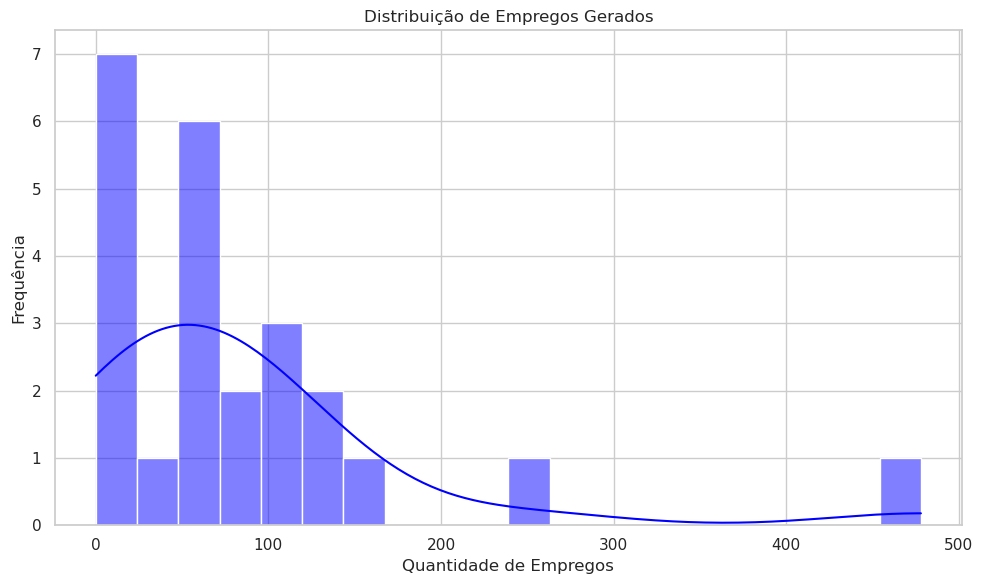

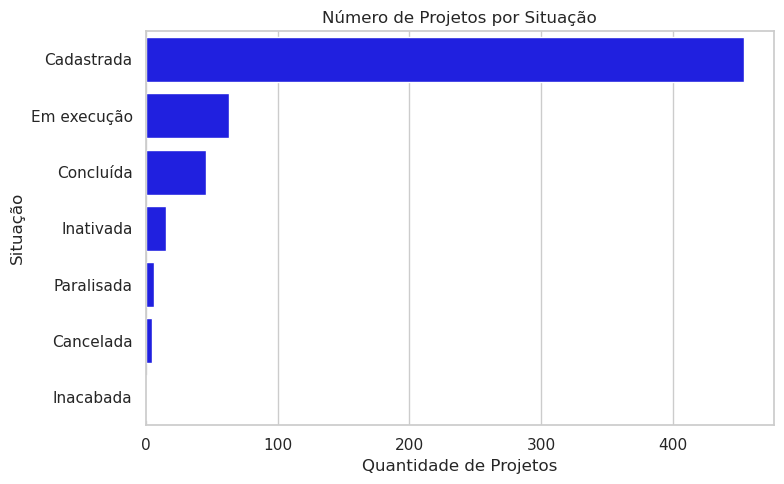

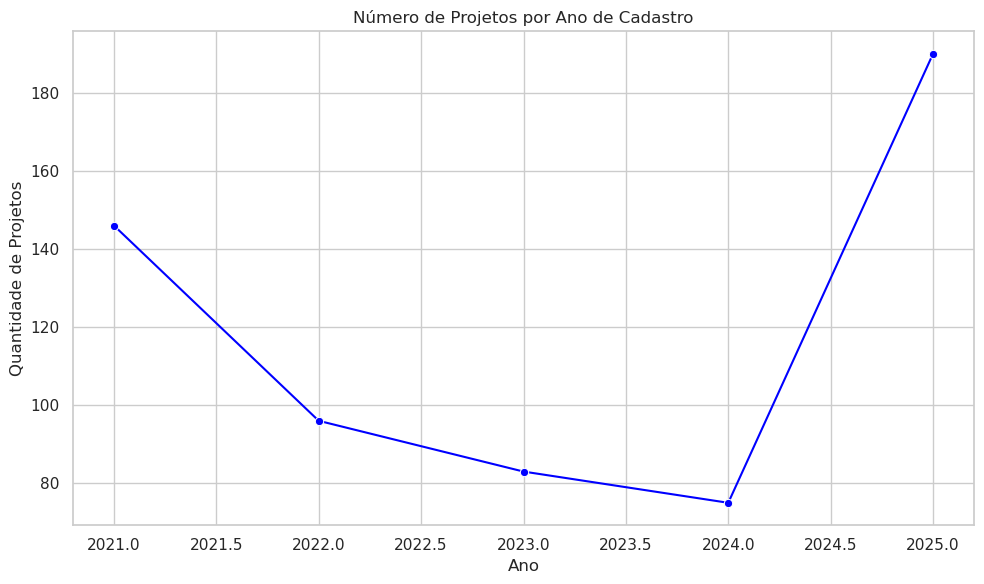

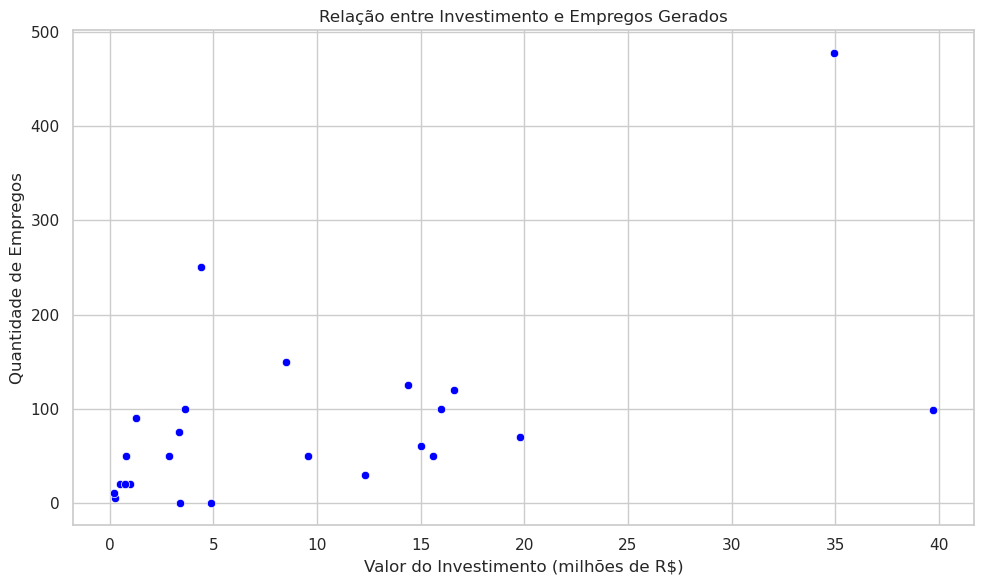

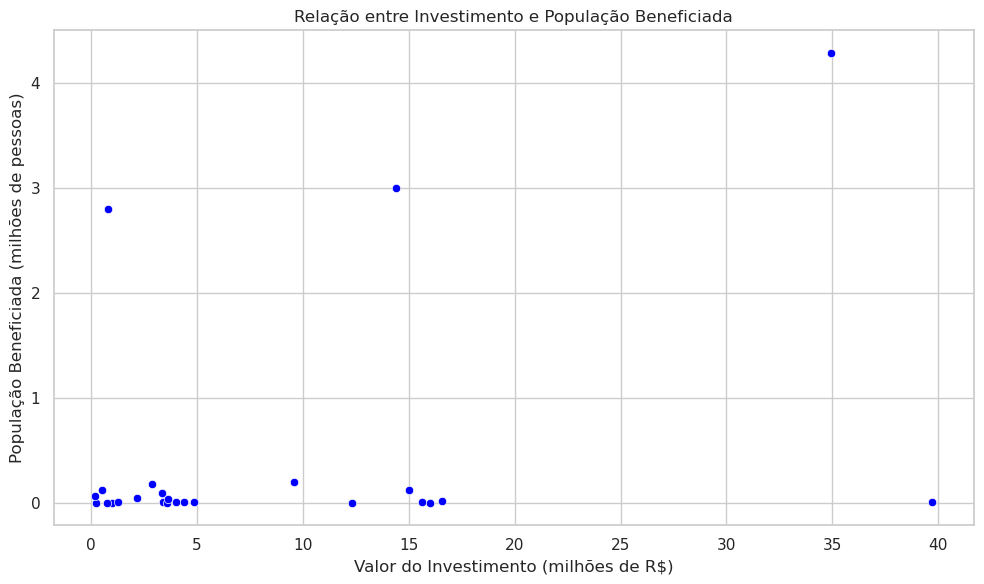

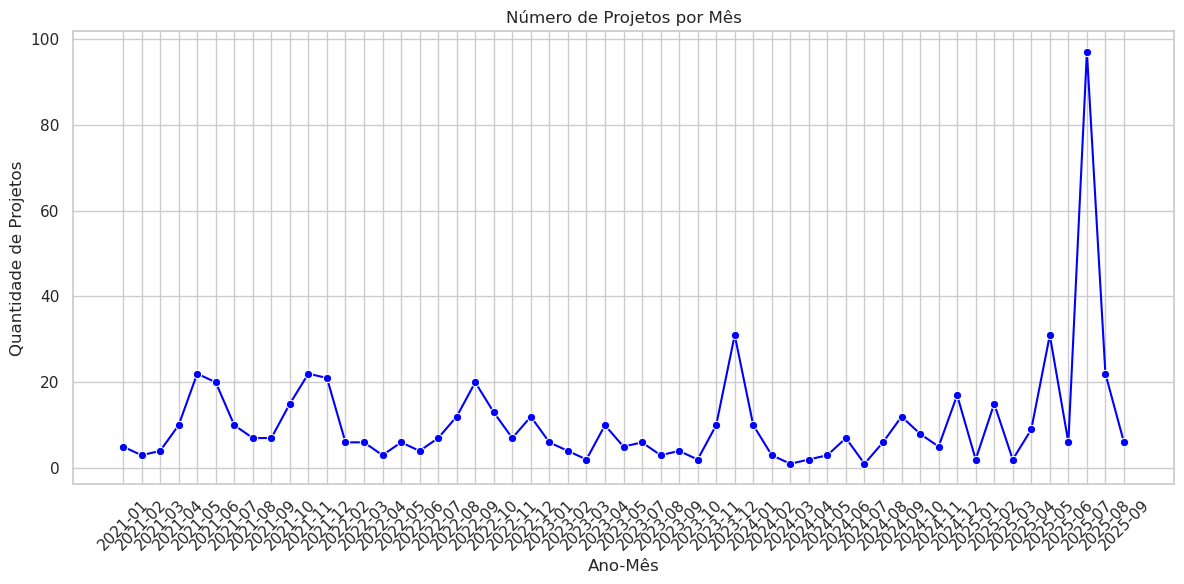

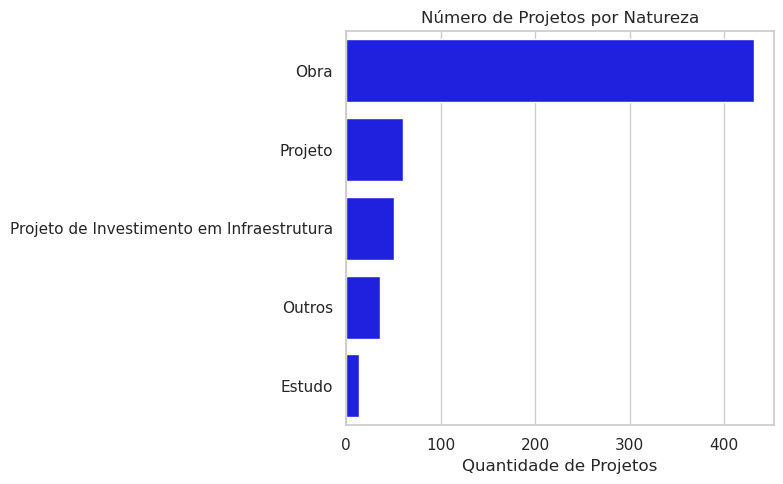

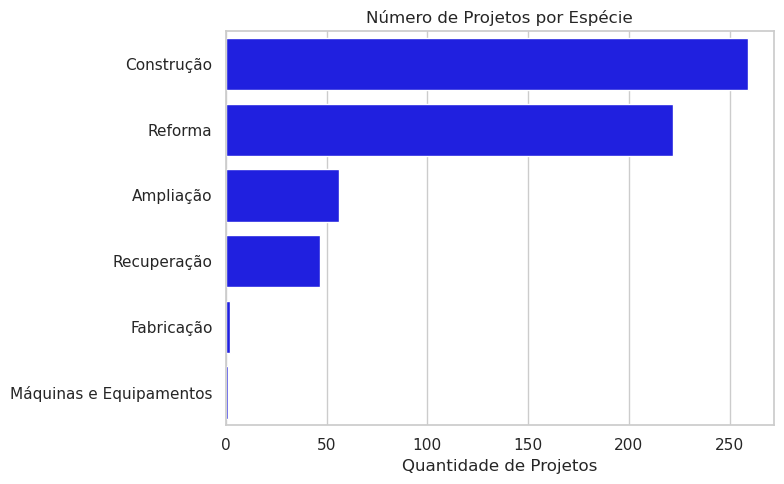

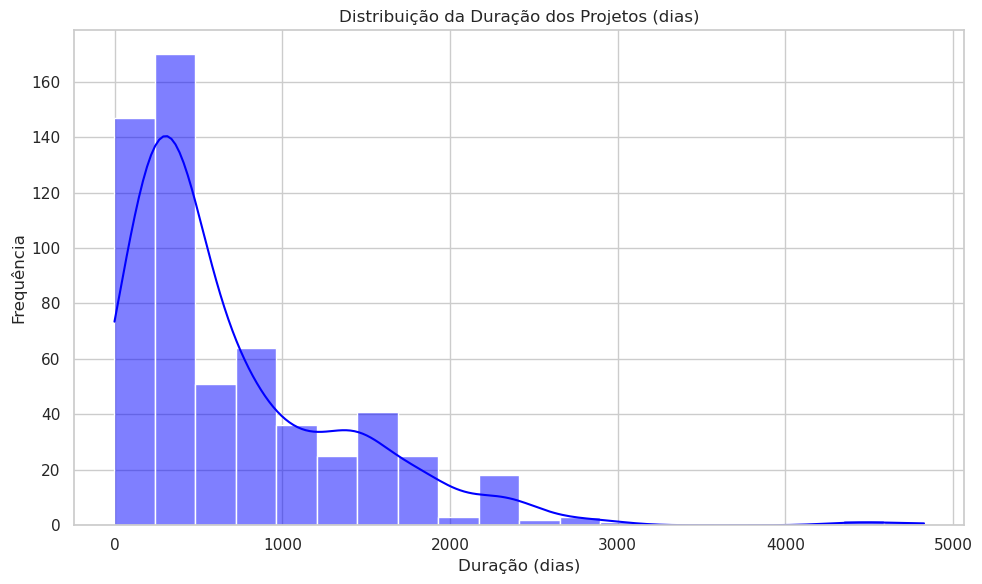

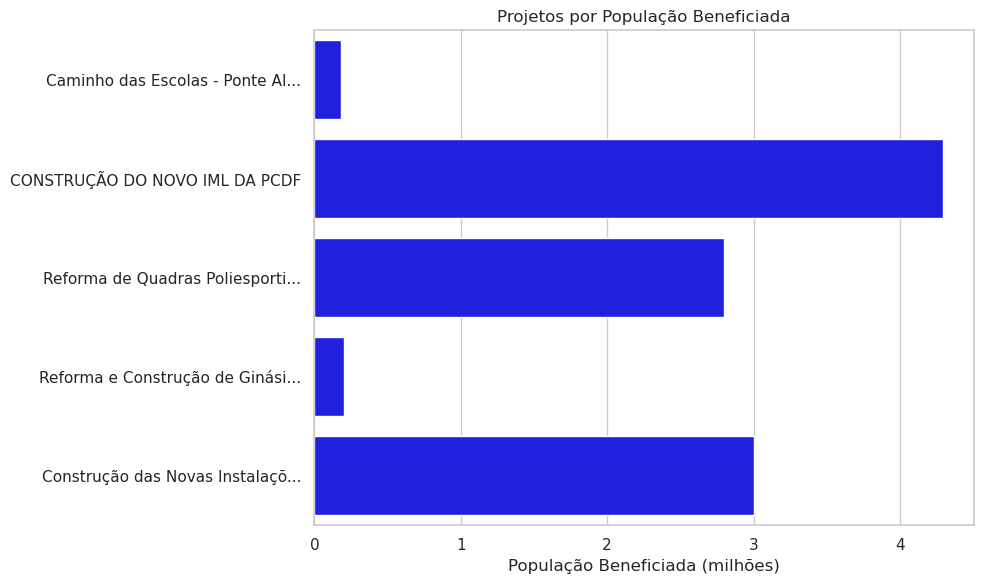

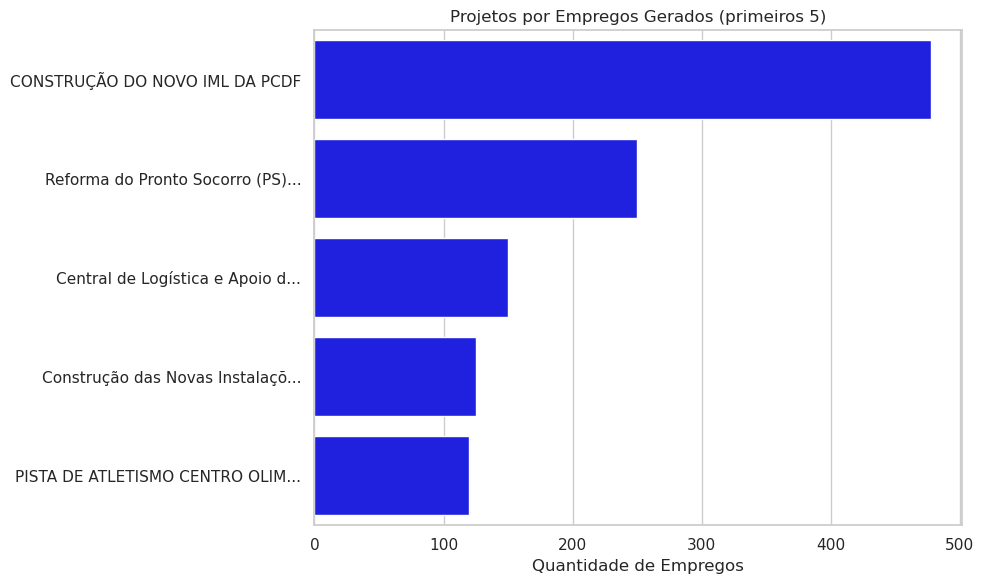

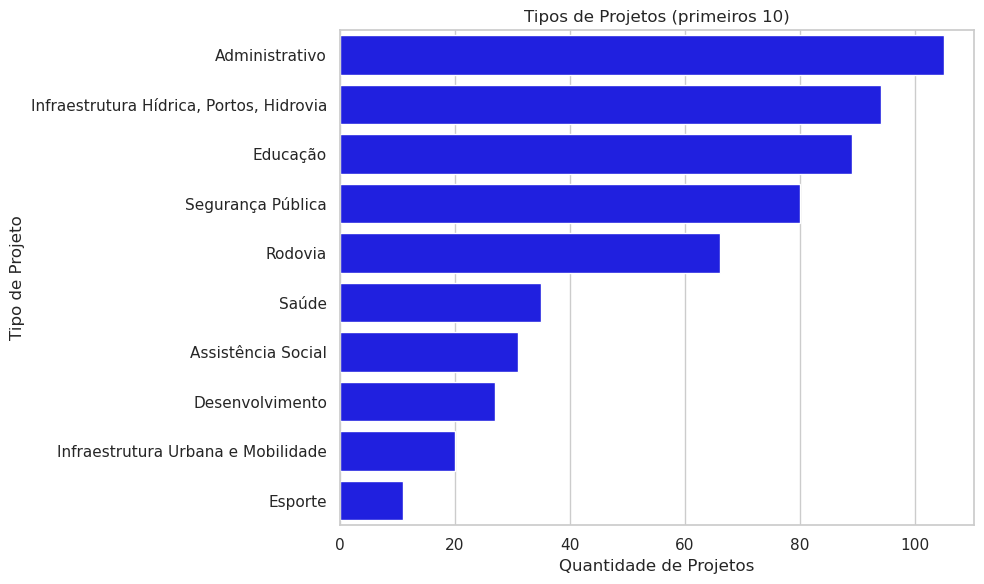

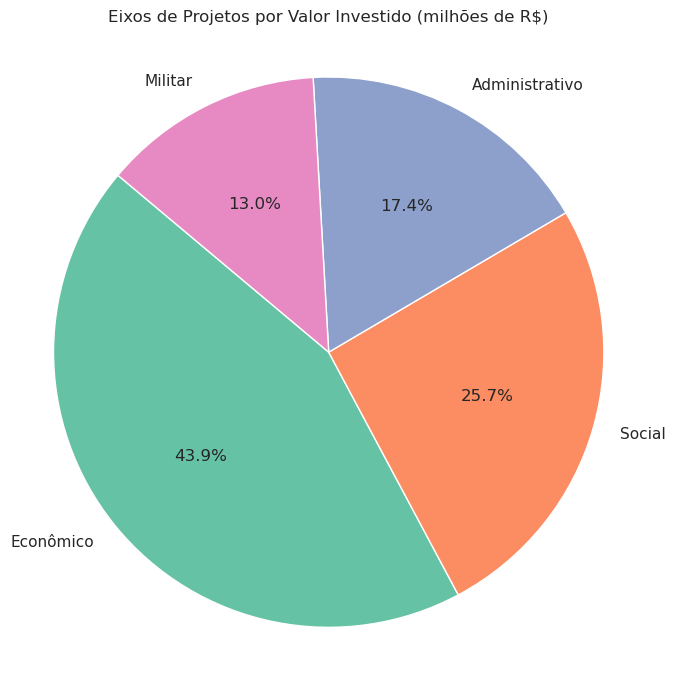

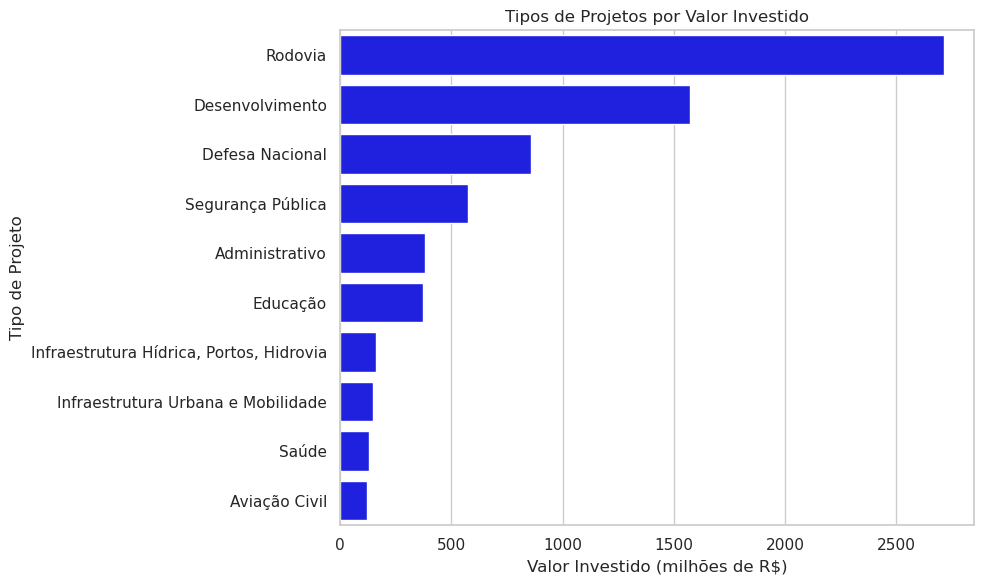

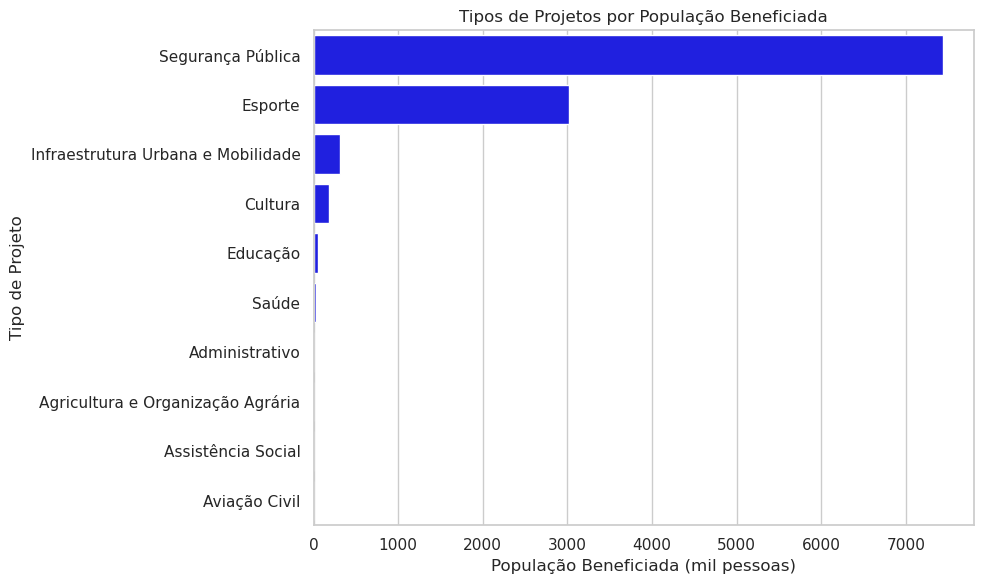

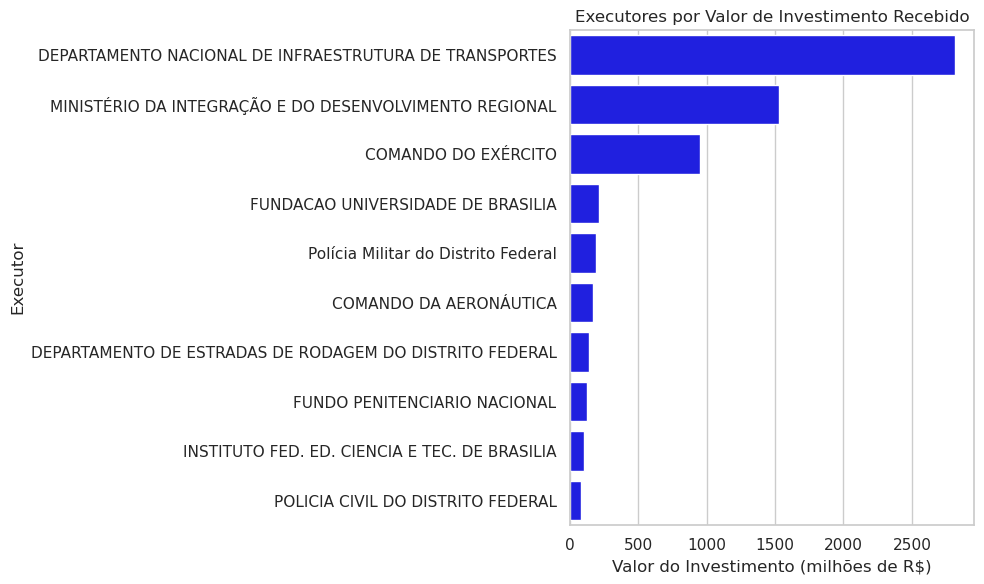

In [175]:
conn = sqlite3.connect(PATH_DB)
df = pd.read_sql_query(
    "SELECT * FROM projetos",
    conn,
    parse_dates=[
        'dataInicialPrevista', 'dataFinalPrevista',
        'dataInicialEfetiva', 'dataFinalEfetiva',
        'dataCadastro', 'dataSituacao'
    ]
)
conn.close()

# GRÁFICOS

sns.set_theme(style="whitegrid")

# a) Distribuição de quantidade de empregos gerados
plt.figure(figsize=(10,6))
sns.histplot(df['quantidadeEmpregosGerados'], bins=20, kde=True, color='blue')
plt.title("Distribuição de Empregos Gerados")
plt.xlabel("Quantidade de Empregos")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# b) Número de projetos por situação (barras horizontais)
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    y='situacao',
    order=df['situacao'].value_counts().index,
    color='blue'
)
plt.title("Número de Projetos por Situação")
plt.xlabel("Quantidade de Projetos")
plt.ylabel("Situação")
plt.tight_layout()
plt.show()

# c) Evolução de projetos por ano
df_grouped = df.groupby(df['dataCadastro'].dt.year).size()
plt.figure(figsize=(10,6))
sns.lineplot(x=df_grouped.index, y=df_grouped.values, marker='o', color='blue')
plt.title("Número de Projetos por Ano de Cadastro")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Projetos")
plt.tight_layout()
plt.show()

# d) Correlação entre empregos gerados e investimento
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x=df['valorInvestimentoPrevistoFontesderecurso'] / 1_000_000,
    y='quantidadeEmpregosGerados',
    color='blue'
)
plt.title("Relação entre Investimento e Empregos Gerados")
plt.xlabel("Valor do Investimento (milhões de R$)")
plt.ylabel("Quantidade de Empregos")
plt.tight_layout()
plt.show()

# e) Correlação entre população beneficiada e investimento
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x=df['valorInvestimentoPrevistoFontesderecurso'] / 1_000_000,  
    y=df['populacaoBeneficiada'] / 1_000_000,
    color='blue'
)
plt.title("Relação entre Investimento e População Beneficiada")
plt.xlabel("Valor do Investimento (milhões de R$)")
plt.ylabel("População Beneficiada (milhões de pessoas)")
plt.tight_layout()
plt.show()

# f) Número de projetos por mês
df['ano_mes'] = df['dataCadastro'].dt.to_period('M')
df_grouped = df.groupby('ano_mes').size().reset_index(name='quantidade')
df_grouped['ano_mes'] = df_grouped['ano_mes'].astype(str)
plt.figure(figsize=(12,6))
sns.lineplot(data=df_grouped, x='ano_mes', y='quantidade', marker='o', color='blue')
plt.xticks(rotation=45)
plt.title("Número de Projetos por Mês")
plt.xlabel("Ano-Mês")
plt.ylabel("Quantidade de Projetos")
plt.tight_layout()
plt.show()


# g) Número de projetos por natureza
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    y='natureza',
    order=df['natureza'].value_counts().index,
    color='blue'
)
plt.title("Número de Projetos por Natureza")
plt.xlabel("Quantidade de Projetos")
plt.ylabel("")
plt.tight_layout()
plt.show()


# h) Número de projetos por espécie
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    y='especie',
    order=df['especie'].value_counts().index,
    color='blue'
)
plt.title("Número de Projetos por Espécie")
plt.xlabel("Quantidade de Projetos")
plt.ylabel("")
plt.tight_layout()
plt.show()

# i) Duração dos projetos (em dias)
df_duracao = df[
    df['dataInicialPrevista'].notnull() & df['dataFinalPrevista'].notnull()
].copy()
df_duracao['duracao_dias'] = (df_duracao['dataFinalPrevista'] - df_duracao['dataInicialPrevista']).dt.days
plt.figure(figsize=(10,6))
sns.histplot(df_duracao['duracao_dias'], bins=20, kde=True, color='blue')
plt.title("Distribuição da Duração dos Projetos (dias)")
plt.xlabel("Duração (dias)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# j) Top 5 projetos por população beneficiada
df_top_pop = df[df['populacaoBeneficiada'].notnull()].nlargest(5, 'populacaoBeneficiada')
df_top_pop['nome_trunc'] = df_top_pop['nome'].apply(lambda x: x[:30] + '...' if len(x) > 30 else x)
plt.figure(figsize=(10,6))
sns.barplot(
    x=df['populacaoBeneficiada'] / 1_000_000,
    y='nome_trunc',
    data=df_top_pop,
    color='blue'
)
plt.title("Projetos por População Beneficiada")
plt.xlabel("População Beneficiada (milhões)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# k) Top 5 projetos por empregos gerados
df_top_emp = df[df['quantidadeEmpregosGerados'].notnull()].nlargest(5, 'quantidadeEmpregosGerados')
df_top_emp['nome_trunc'] = df_top_emp['nome'].apply(lambda x: x[:30] + '...' if len(x) > 30 else x)
plt.figure(figsize=(10,6))
sns.barplot(
    x='quantidadeEmpregosGerados',
    y='nome_trunc',
    data=df_top_emp,
    color='blue'
)
plt.title("Projetos por Empregos Gerados (primeiros 5)")
plt.xlabel("Quantidade de Empregos")
plt.ylabel("")
plt.tight_layout()
plt.show()


# l) Principais tipos de projetos
top_tipos = df['descricaoTipos'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_tipos.values,
    y=top_tipos.index,
    color='blue'
)
plt.title("Tipos de Projetos (primeiros 10)")
plt.xlabel("Quantidade de Projetos")
plt.ylabel("Tipo de Projeto")
plt.tight_layout()
plt.show()


# m) Valor investido por eixo de projeto
top_eixos_valor = df.groupby('descricaoEixos')['valorInvestimentoPrevistoFontesderecurso'].sum().nlargest(5)

plt.figure(figsize=(7,7))
plt.pie(
    top_eixos_valor.values / 1_000_000,  # converter para milhões
    labels=top_eixos_valor.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set2", len(top_eixos_valor))
)
plt.title("Eixos de Projetos por Valor Investido (milhões de R$)")
plt.axis('equal')
plt.tight_layout()
plt.show()

# n) Valor investido por tipo de projeto
top_tipos_valor = df.groupby('descricaoTipos')['valorInvestimentoPrevistoFontesderecurso'].sum().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_tipos_valor.values / 1_000_000, 
    y=top_tipos_valor.index,
    color='blue'
)
plt.title("Tipos de Projetos por Valor Investido")
plt.xlabel("Valor Investido (milhões de R$)")
plt.ylabel("Tipo de Projeto")
plt.tight_layout()
plt.show()

# o) População beneficiada por tipo de projeto
top_tipos_pop = df.groupby('descricaoTipos')['populacaoBeneficiada'].sum().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_tipos_pop.values / 1_000,
    y=top_tipos_pop.index,
    color='blue'
)
plt.title("Tipos de Projetos por População Beneficiada")
plt.xlabel("População Beneficiada (mil pessoas)")
plt.ylabel("Tipo de Projeto")
plt.tight_layout()
plt.show()

# p) Top 10 executores por investimento recebido
top_executores_valor = (
    df.groupby('nomeExecutores')['valorInvestimentoPrevistoFontesderecurso']
    .sum()
    .nlargest(10)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_executores_valor.values / 1_000_000,
    y=top_executores_valor.index,
    color='blue'
)
plt.title("Executores por Valor de Investimento Recebido")
plt.xlabel("Valor do Investimento (milhões de R$)")
plt.ylabel("Executor")
plt.tight_layout()
plt.show()

## 6. Conclusões Finais

### 1. Grande Volume de Projetos Aguardando Execução

O dado mais alarmante é a enorme concentração de projetos na situação "Cadastrada". Isso indica um grande portfólio de intenções que ainda não se converteram em ações. É um ponto de atenção gerencial: há um gargalo impedindo o início desses projetos? Trata-se de uma estratégia de registrar projetos para garantir orçamento futuro ou há uma limitação na capacidade de execução?

### 2. Crescimento Exponencial e Variação Ligada a Ciclos Eleitorais

O número de projetos cadastrados por ano apresenta uma dinâmica que sugere uma forte influência do calendário político.

Observação sobre 2021 e 2025: O número relativamente alto de projetos em 2021 e o pico exponencial em 2025 podem estar associados a ciclos eleitorais. É um fenômeno comum que governos intensifiquem o cadastro e a divulgação de obras e projetos em períodos que antecedem eleições, como as de 2022 (influenciando 2021) e as de 2026 (influenciando 2025). Essa aceleração pode ser uma estratégia para apresentar realizações e promessas à população, buscando capital político. A queda entre esses picos reforça a ideia de uma gestão de portfólio cíclica e reativa, em vez de um fluxo contínuo de planejamento e execução.

### 3. Foco em Obras de Infraestrutura

A carteira é majoritariamente composta por projetos de "Obra", com foco em "Construção" e "Reforma". Setorialmente, projetos "Administrativos" são os mais numerosos, mas os maiores investimentos estão concentrados em "Rodovia" e "Desenvolvimento". Isso mostra que, embora a burocracia gere muitas iniciativas, os recursos financeiros estão direcionados para grandes obras de infraestrutura, que frequentemente têm grande visibilidade.

### 4. Relação Incerta entre Investimento e Impacto

Os gráficos de dispersão mostram que não há uma correlação clara entre o valor investido e os benefícios gerados (empregos e população beneficiada). Isso pode ser agravado pelo contexto eleitoral, onde o objetivo principal de um projeto pode ser a visibilidade e o impacto político, e não necessariamente a otimização do retorno socioeconômico.

- Pontos Fora da Curva: Existem poucos projetos que são "campeões" de impacto. Esses casos de sucesso devem ser estudados para entender o que os torna tão eficientes.

- Dados Ausentes: A grande concentração de projetos próximos ao eixo zero pode indicar tanto projetos de baixo impacto quanto, mais provavelmente, projetos cujo impacto ainda não foi mensurado ou reportado nos dados.

### 5. O Impacto Social Vem de Setores Específicos

Enquanto os maiores investimentos estão em rodovias, o maior benefício populacional reportado vem de projetos de "Segurança Pública" e "Esporte", como a "CONSTRUÇÃO DO NOVO IML DA PCDF". Isso sugere que projetos de infraestrutura social podem ter um retorno para a população mais direto, sendo também estratégicos em termos de percepção pública.

**Observação Importante: Qualidade e Completude dos Dados**

É crucial destacar que uma análise aprofundada pode ser limitada pela qualidade dos dados de origem. A ausência de informações completas em muitos projetos pode distorcer algumas das conclusões. As observações são baseadas estritamente nos dados apresentados e devem ser vistas como um retrato do que foi reportado.

**Além disso, mais gráficos podem ser vistos no servidor streamlit (para rodar o servidor localmente, só seguir o passo a passo descrito no README.md deste repositório)**